# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from scipy.stats import ttest_ind, norm
from scipy.integrate import quad 

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [5]:
from core.dgp import RCTs, DataGenerationProcess
import core.rct as rct
from core.variables import *
from core.utils import *

# DGP

In [ ]:
# bernoulli specification
dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(0.1), PointMass(0.11)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'response_type': 'bernoulli', 
    'dgp_seed': 0
}

# # continuous specification
# dgp_params = {
#     'n_experiments': 1, 
#     'base_effects': [PointMass(1), PointMass(1.05)],
#     'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
#     'dgp_seed': 0
# }

# # logit specification
# dgp_params = {
#     'n_experiments': 1, 
#     'base_effects': [PointMass(np.log(1 / 9)), PointMass(np.log(11 / 89))],
#     'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
#     'response_type': 'logit', 
#     'dgp_seed': 0
# }

dgp = RCTs(**dgp_params)

In [353]:
samples = dgp.sample(sample_size=1000000, seed=0)

# Estimation

In [156]:
emp_te_arr, emp_var_arr = rct.estimate_treatment_effects(samples, response_type=dgp.response_type)

# Selection

In [157]:
selection = rct.select_higher_effect(treatment_effects=emp_te_arr, treatment_vars=emp_var_arr)

# Evaluation

In [158]:
val_est = rct.obj_func(selection=selection, treatment_effects=emp_te_arr, response_type=dgp.response_type,)
val_true = rct.obj_func(selection=selection, treatment_effects=dgp.treatment_effects, response_type=dgp.response_type,)

result_df = pd.DataFrame({
    'Rank and Select': [val_est, val_true, val_est - val_true]
}, index=['Estimated Policy Value', 'True Policy Value', 'Winner\'s Curse'])
result_df

,Rank and Select
Estimated Policy Value,0.11
True Policy Value,0.11
Winner's Curse,0.00


In [12]:
del dgp, samples, emp_te_arr, selection, val_est, val_true, result_df

# Winner's Curse

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(np.log(1 / 9)), PointMass(np.log(11 / 89))],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'response_type': 'logit', 
    'dgp_seed': 0
}


data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 500}

estimators_dict = {}

result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  41 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.1s finished


In [18]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    # unpack results
    wc_arr = np.array([result[f'{optimizer}_wc'] for result in result_records])
    val_true_arr = np.array([result[f'{optimizer}_val_true'] for result in result_records])
    val_est_arr = np.array([result[f'{optimizer}_val_est'] for result in result_records])

    wc_avg = wc_arr.mean()
    wc_se = wc_arr.std() / data_params['sample_size'] ** 0.5 

    val_true_avg = val_true_arr.mean()
    val_true_se = val_true_arr.std() / data_params['sample_size'] ** 0.5
    val_est_avg = val_est_arr.mean()
    val_est_se = val_est_arr.std() / data_params['sample_size'] ** 0.5

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.6f} ({val_true_se:.6f})')
    print(f'  - Average Estimated Value: {val_est_avg:.6f} ({val_est_se:.6f})')
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.4%} ({wc_se/delta_tau:.4%})')


Selection with Rank and Select:
  - Average True Value: 0.107040 (0.000204)
  - Average Estimated Value: 0.114292 (0.000554)
  - Average Winner's Curse (%): 6.8104% (0.5165%)


# Estimating Winner's Curse

In [464]:
dgp = RCTs(**dgp_params)
samples = dgp.sample(sample_size=data_params['sample_size'], seed=0)

## Standard Bootstrap

In [465]:
boot_wc_dstn_dict = rct.get_wc_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    response_type=dgp.response_type,
    n_bootstraps=1000, n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.3s finished


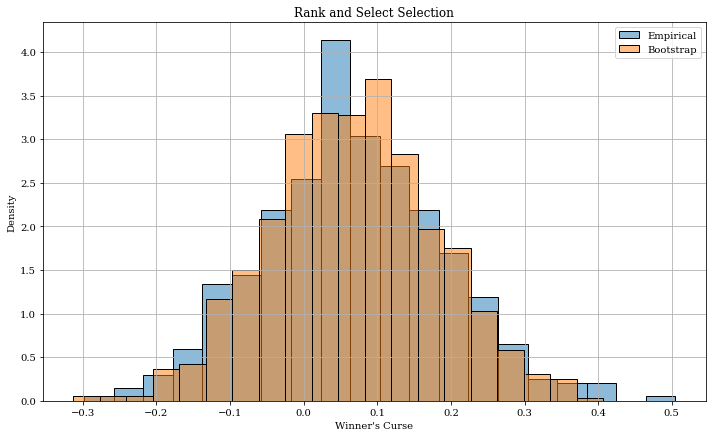

In [466]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [ ]:
boot_wc_dstn_dict = rct.get_wc_m_out_of_n_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    response_type=dgp.response_type,
    n_bootstraps=1000, power=0.95, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


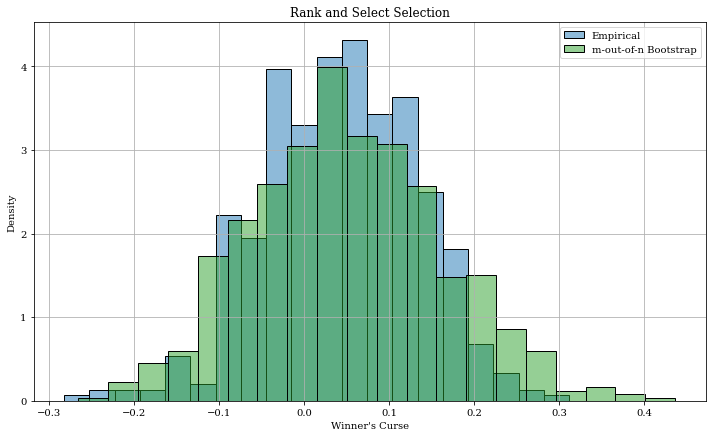

In [ ]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [ ]:
boot_wc_dstn_dict = rct.get_wc_num_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    response_type=dgp.response_type, 
    n_bootstraps=1000, power=-0.45, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


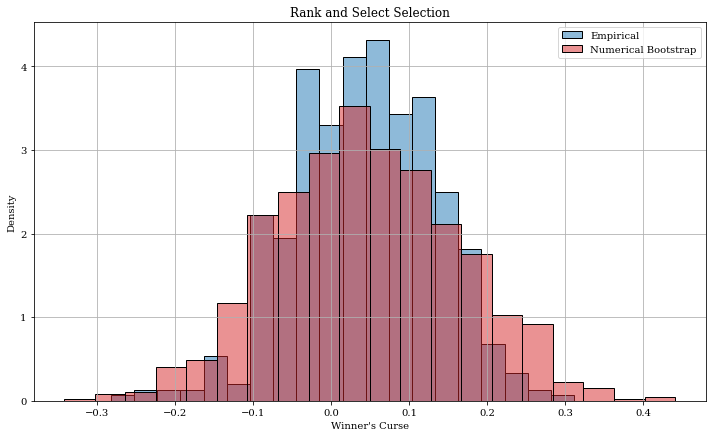

In [ ]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='Numerical Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

In [ ]:
del dgp, samples, boot_wc_dstn_dict

# Bias Correction

In [317]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.05)],
    'response_type': 'continuous', 
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 50000}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    # 'eb_tweedies': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'tweedies', 'dof': 3, 'bin_width': 0.2, 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Tweedies)'
    # }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    'hybrid_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI'
    }, 
}

In [ ]:
result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = rct.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)


Selection with Rank and Select:
Policy Value: 
  - True Value: 1.0393 (0.0006)
  - No Correction: 1.0579 (0.0013)
  - Standard Bootstrap: 1.0430 (0.0015)
  - m-out-of-n Bootstrap: 1.0385 (0.0015)
  - Numerical Bootstrap: 1.0374 (0.0015)
  - Empirical Bayes: 1.0414 (0.0012)
  - Conditional SI: 0.9913 (0.0099)
  - Hybrid SI: 1.0318 (0.0021)

Winner's Curse: 
Average Winner's Curse: 
  - No Correction: 37.28% (2.59%)
  - Standard Bootstrap: 7.42% (2.85%)
  - m-out-of-n Bootstrap: -1.56% (2.87%)
  - Numerical Bootstrap: -3.77% (2.95%)
  - Empirical Bayes: 4.12% (2.52%)
  - Conditional SI: -96.01% (19.55%)
  - Hybrid SI: -15.08% (4.00%)
Median Winner's Curse: 
  - No Correction: 36.58% (2.59%)
  - Standard Bootstrap: 5.58% (2.85%)
  - m-out-of-n Bootstrap: -3.47% (2.87%)
  - Numerical Bootstrap: -8.08% (2.95%)
  - Empirical Bayes: 2.66% (2.52%)
  - Conditional SI: 2.38% (19.55%)
  - Hybrid SI: 2.55% (4.00%)

Sample Splitting: 
  - True Value: 1.0350 (0.0007)
  - Estimated Value: 1.0369 (0.

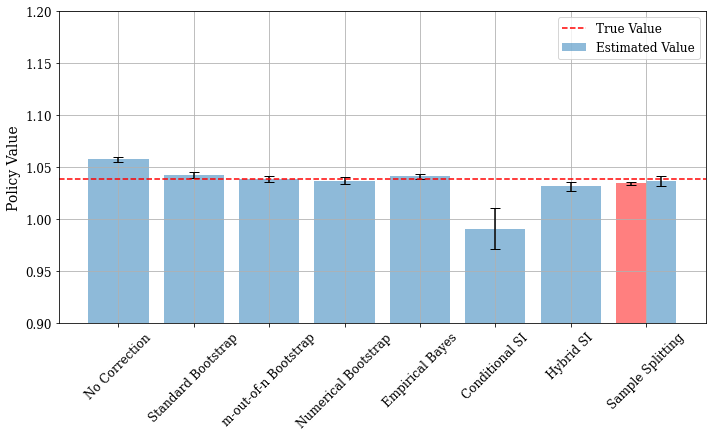

In [ ]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

optimizer_key = 'rank_and_select'

print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    est_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average Winner's Curse: ")
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median Winner\'s Curse: ')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_median = np.nanmedian(wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'\nSample Splitting: ')
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(estimators_dict.keys()) + 1 - int('sample_splitting' in estimators_dict.keys()))
bar_values = [
    wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]
bar_errors = [
    1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
if 'sample_splitting' in estimators_dict.keys():
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items() if k != 'sample_splitting'] + ['Sample Splitting'], 
        rotation=45, 
        fontsize=tick_label_size
    )
else:
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items()]
    )
ax.set_ylim([0.9, 1.2])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


In [ ]:
np.mean(wc_measures_dict[f'{optimizer_key}_conditional_si_val_est_arr']), np.mean(wc_measures_dict[f'{optimizer_key}_conditional_si_wc_arr'])/ 0.05 * 100

(0.9912943212834632, -96.01135743307398)

In [ ]:
np.median(wc_measures_dict[f'{optimizer_key}_conditional_si_val_est_arr']), np.median(wc_measures_dict[f'{optimizer_key}_conditional_si_wc_arr'])/ 0.05 * 100

(1.0432993866966709, 2.379718911583728)

In [ ]:
np.median(wc_measures_dict[f'{optimizer_key}_hybrid_si_val_est_arr']), np.median(wc_measures_dict[f'{optimizer_key}_hybrid_si_wc_arr']) / 0.05 * 100

(1.0433732068920367, 2.55142637864747)

In [ ]:
optimizer_key= 'rank_and_select'
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean
latex_dict = {}

# true value
val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
latex_dict["True Value"] = {
    'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${val_true_avg:.4f}$\\\\ (${val_true_se:.4f}$)" + "\end{tabular}", 
    r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${0:.2f}\%$\\\\ (${0:.2f}\%$)" + "\end{tabular}"
}

for e_key in ['nc'] + list(estimators_dict.keys()):
    if e_key == 'sample_splitting':
        continue
    
    est_mean = wc_measures_dict[f'{optimizer_key}_{e_key}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{e_key}_val_est_se']

    wc_mean = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_{e_key}_wc_avg']
    wc_se = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_{e_key}_wc_se']
    wc_sig_level = significance_level(wc_mean, wc_se)
    wc_sig_level = '^{' + wc_sig_level + '}' if wc_sig_level != '' else ''

    e_name =  estimators_dict[e_key]['display_name'] if e_key != 'nc' else 'No Correction'

    latex_dict[e_name] = {
        'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${est_mean:.4f}" + f"$\\\\ (${est_se:.4f}$)" + "\end{tabular}", 
        r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + wc_sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    }

# sample splitting
ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']

ss_wc_avg = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
ss_wc_se = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']
ss_wc_sig_level = significance_level(ss_wc_avg, ss_wc_se)
ss_wc_sig_level = '^{' + ss_wc_sig_level + '}' if ss_wc_sig_level != '' else ''
latex_dict["Sample Splitting"] = {
    'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_est_avg:.4f}" + f"$\\\\ (${ss_val_est_se:.4f}$)" + "\end{tabular}",
    r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_wc_avg:.2f}\%" + ss_wc_sig_level + f"$\\\\ (${ss_wc_se:.2f}\%$)" + "\end{tabular}"
}

latex_df = pd.DataFrame(latex_dict).T
print(latex_df.style.to_latex(
    column_format='ccc',  
    hrules=True
))

\begin{tabular}{ccc}
\toprule
 & Policy Value & \begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular} \\
\midrule
True Value & \begin{tabular}[c]{@{}c@{}}$1.0393$\\ ($0.0006$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.00\%$\\ ($0.00\%$)\end{tabular} \\
No Correction & \begin{tabular}[c]{@{}c@{}}$1.0579$\\ ($0.0013$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$37.28\%^{***}$\\ ($2.59\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$1.0430$\\ ($0.0015$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$7.42\%^{***}$\\ ($2.85\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$1.0385$\\ ($0.0015$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-1.56\%$\\ ($2.87\%$)\end{tabular} \\
Numerical Bootstrap & \begin{tabular}[c]{@{}c@{}}$1.0374$\\ ($0.0015$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-3.77\%$\\ ($2.95\%$)\end{tabular} \\
Empirical Bayes & \begin{tabular}[c]{@{}c@{}}$1.0414$\\ ($0.0012$)\end{tabular} & \begin{tabular}[c]{@{

In [ ]:
nc_val_true_avg  = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
nc_val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
clairvoyant_val = np.max([var.mean for var in dgp_params['base_effects']])
policy_comp_dict = {
    'Clairvoyant Policy': {'Policy Value': f"{clairvoyant_val:.4f}"}, 
    'Focal Policy': {'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${nc_val_true_avg:.4f}" + f"$\\\\ (${nc_val_true_se:.4f}$)" + "\end{tabular}"},
}

ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
random_val = np.mean([var.mean for var in dgp_params['base_effects']])
policy_comp_dict.update({
    'Sample Splitting': {'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_true_avg:.4f}" + f"$\\\\ (${ss_val_true_se:.4f}$)" + "\end{tabular}"}, 
    'Random Guessing': {'Policy Value': f'{random_val:.4f}'},
})

policy_comp_df = pd.DataFrame(policy_comp_dict).T
print(policy_comp_df.style.to_latex(
    column_format='cc',  
    hrules=True
))

\begin{tabular}{cc}
\toprule
 & Policy Value \\
\midrule
Clairvoyant Policy & 1.0500 \\
Focal Policy & \begin{tabular}[c]{@{}c@{}}$1.0393$\\ ($0.0006$)\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}$1.0387$\\ ($0.0007$)\end{tabular} \\
Random Guessing & 1.0250 \\
\bottomrule
\end{tabular}



# Comparative Statics

## Delta Tau

In [366]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Spike-Slab)'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    'hybrid_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI'
    }, 
}

### $\tau_1 = 1.0$

In [339]:
base_tau = 1.0
delta_tau_list = [0.01, 0.025, 0.05]

delta_tau1_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta tau= {delta_tau}')
    
    dgp_params['base_effects'] = [PointMass(base_tau), PointMass(base_tau + delta_tau)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    delta_tau1_result_dict[delta_tau] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Delta tau= 0.01
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.025
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.05
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.5s finished


In [367]:
# with open('results/ab_test_delta_tau1.pkl', 'wb') as f:
#     pickle.dump(delta_tau1_result_dict, f)

with open('results/ab_test_delta_tau1.pkl', 'rb') as f:
    delta_tau1_result_dict = pickle.load(f)

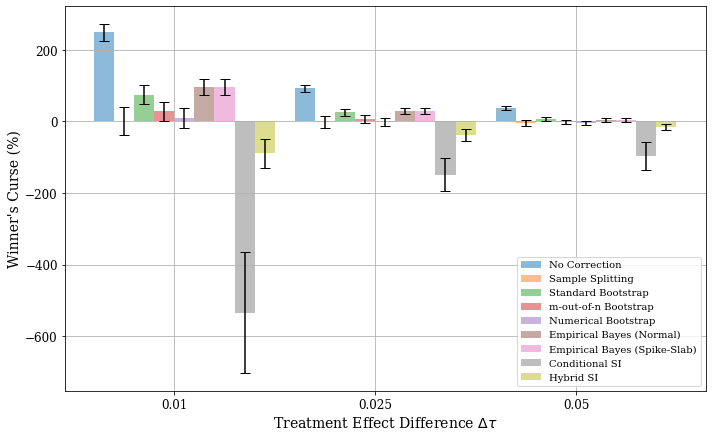

$\Delta\tau=0.01$  $\Delta\tau=0.025$  \
No Correction                Mean               249.24               92.30   
                             Median             241.51               89.38   
                             S.E.                11.89                4.95   
Sample Splitting             Mean                 1.16               -1.35   
                             Median              17.44                3.92   
                             S.E.                20.26                8.45   
Standard Bootstrap           Mean                74.97               25.05   
                             Median              44.50               16.11   
                             S.E.                13.15                5.46   
m-out-of-n Bootstrap         Mean                28.19                6.32   
                             Median              -6.23               -3.12   
                             S.E.                13.21                5.49   
Numerical Bootstrap          Mean                 9.55               -0.24   
                             Median             -36.39              -11.64   
                             S.E.                13.67                5.67   
Empirical Bayes (Normal)     Mean                96.40               29.78   
                             Median              85.21               24.70   
                             S.E.                11.16                4.70   
Empirical Bayes (Spike-Slab) Mean                96.20               29.70   
                             Median              85.04               24.62   
                             S.E.                11.16                4.70   
Conditional SI               Mean              -534.45             -148.50   
                             Median              12.94               -2.52   
                             S.E.                86.36               23.14   
Hybrid SI                    Mean               -89.04              -37.82   
                             Median              10.86               -5.04   
                             S.E.                21.06                8.48   

                                     $\Delta\tau=0.05$  
No Correction                Mean                37.28  
                             Median              36.58  
                             S.E.                 2.59  
Sample Splitting             Mean                -4.72  
                             Median               2.89  
                             S.E.                 4.44  
Standard Bootstrap           Mean                 7.42  
                             Median               5.58  
                             S.E.                 2.85  
m-out-of-n Bootstrap         Mean                -1.56  
                             Median              -3.47  
                             S.E.                 2.87  
Numerical Bootstrap          Mean                -3.77  
                             Median              -8.08  
                             S.E.                 2.95  
Empirical Bayes (Normal)     Mean                 4.12  
                             Median               2.66  
                             S.E.                 2.52  
Empirical Bayes (Spike-Slab) Mean                 4.08  
                             Median               2.62  
                             S.E.                 2.52  
Conditional SI               Mean               -96.01  
                             Median               2.38  
                             S.E.                19.55  
Hybrid SI                    Mean               -15.08  
                             Median               2.55  
                             S.E.                 4.00

In [368]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = delta_tau1_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    data[delta_tau]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[delta_tau][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for delta_tau in delta_tau_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[delta_tau][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\Delta\tau={}$'.format(d) for d in delta_tau_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(delta_tau_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[dt][estimator]['Mean'] for dt in delta_tau_list]
    bar_errors = [1.96 * data[dt][estimator]['S.E.'] for dt in delta_tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Treatment Effect Difference $\Delta\tau$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(delta_tau_list)), labels=delta_tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [369]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = delta_tau1_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    wc_mean = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[delta_tau]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[delta_tau][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
sigma = dgp_params['noise_vars'][0].std
latex_df.columns = [f'$\Delta\\tau / \sigma={100 * delta_tau / sigma:.1f}\%$' for delta_tau in delta_tau_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(delta_tau_list) + 1), 
    hrules=True
))

\begin{tabular}{cccc}
\toprule
 & $\Delta\tau / \sigma=1.0\%$ & $\Delta\tau / \sigma=2.5\%$ & $\Delta\tau / \sigma=5.0\%$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$249.24\%^{***}$\\ ($11.89\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$92.30\%^{***}$\\ ($4.95\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$37.28\%^{***}$\\ ($2.59\%$)\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}$1.16\%$\\ ($20.26\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-1.35\%$\\ ($8.45\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-4.72\%$\\ ($4.44\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$74.97\%^{***}$\\ ($13.15\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$25.05\%^{***}$\\ ($5.46\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$7.42\%^{***}$\\ ($2.85\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$28.19\%^{**}$\\ ($13.21\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$6.32\%$\\ ($5.49\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}

In [374]:
policy_comp_dict = {
    'Clairvoyant Policy': {}, 
    'Policy (Entire Dataset)': {},
    'Policy (Half Dataset)': {},
    'Random Guessing': {}, 
}

for delta_tau, wc_measures_dict in delta_tau1_result_dict.items():
    ratio = delta_tau / 1.0 * 100
    # clairvoyant policy
    clairvoyant_val = 1 + delta_tau
    policy_comp_dict['Clairvoyant Policy'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = f"{clairvoyant_val:.4f}"

    # focal policy
    nc_val_true_avg  = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
    nc_val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
    policy_comp_dict['Policy (Entire Dataset)'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${nc_val_true_avg:.4f}" + f"$\\\\ (${nc_val_true_se:.4f}$)" + "\end{tabular}"

    # sample splitting
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    policy_comp_dict['Policy (Half Dataset)'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_true_avg:.4f}" + f"$\\\\ (${ss_val_true_se:.4f}$)" + "\end{tabular}"

    # random guessing policy 
    random_val = 1 + delta_tau / 2 
    policy_comp_dict['Random Guessing'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = f'{random_val:.4f}'

# Create DataFrame
policy_comp_df = pd.DataFrame(policy_comp_dict).T 
policy_comp_df
print(policy_comp_df.style.to_latex(
    column_format='cccc',  
    hrules=True
))

\begin{tabular}{cccc}
\toprule
 & $\Delta\tau / \sigma = 1.0\%$ & $\Delta\tau / \sigma = 2.5\%$ & $\Delta\tau / \sigma = 5.0\%$ \\
\midrule
Clairvoyant Policy & 1.0100 & 1.0250 & 1.0500 \\
Policy (Entire Dataset) & \begin{tabular}[c]{@{}c@{}}$1.0056$\\ ($0.0002$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0167$\\ ($0.0004$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0393$\\ ($0.0006$)\end{tabular} \\
Policy (Half Dataset) & \begin{tabular}[c]{@{}c@{}}$1.0055$\\ ($0.0002$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0149$\\ ($0.0004$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0350$\\ ($0.0007$)\end{tabular} \\
Random Guessing & 1.0050 & 1.0125 & 1.0250 \\
\bottomrule
\end{tabular}



### $\tau_1 = 2.0$

In [17]:
base_tau = 2.0
delta_tau_list = [0.01, 0.05, 0.1, 0.5]

delta_tau2_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta tau= {delta_tau}')
    
    dgp_params['base_effects'] = [PointMass(base_tau), PointMass(base_tau + delta_tau)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    delta_tau2_result_dict[delta_tau] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Delta tau= 0.01
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:    7.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.05
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta tau= 0.5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.3s finished


In [18]:
with open('results/ab_test_delta_tau2.pkl', 'wb') as f:
    pickle.dump(delta_tau2_result_dict, f)

with open('results/ab_test_delta_tau2.pkl', 'rb') as f:
    delta_tau2_result_dict = pickle.load(f)

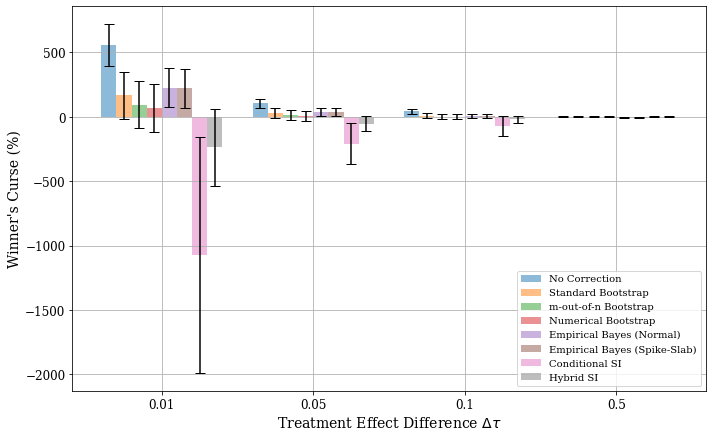

$\Delta\tau=0.01$  $\Delta\tau=0.05$  \
No Correction                Mean               557.93             104.41   
                             Median             581.37             111.14   
                             S.E.                83.15              16.99   
Standard Bootstrap           Mean               166.07              28.27   
                             Median             149.28              25.23   
                             S.E.                92.93              18.92   
m-out-of-n Bootstrap         Mean                92.06              13.49   
                             Median              59.35               9.82   
                             S.E.                92.85              18.91   
Numerical Bootstrap          Mean                66.38               8.69   
                             Median              62.25               4.59   
                             S.E.                95.59              19.44   
Empirical Bayes (Normal)     Mean               225.20              37.02   
                             Median             255.74              40.89   
                             S.E.                77.23              16.01   
Empirical Bayes (Spike-Slab) Mean               222.99              36.58   
                             Median             252.95              40.53   
                             S.E.                77.23              16.01   
Conditional SI               Mean             -1074.33            -207.95   
                             Median              73.82               5.99   
                             S.E.               468.06              81.55   
Hybrid SI                    Mean              -237.70             -53.30   
                             Median              36.26               3.86   
                             S.E.               151.18              30.71   

                                     $\Delta\tau=0.1$  $\Delta\tau=0.5$  
No Correction                Mean               43.15             -0.02  
                             Median             44.99             -0.12  
                             S.E.                9.10              2.02  
Standard Bootstrap           Mean                8.42             -0.34  
                             Median              9.37              0.04  
                             S.E.                9.99              2.07  
m-out-of-n Bootstrap         Mean                1.13             -0.61  
                             Median              1.23             -0.78  
                             S.E.               10.03              2.08  
Numerical Bootstrap          Mean               -0.59             -0.47  
                             Median             -0.15             -0.64  
                             S.E.               10.24              2.08  
Empirical Bayes (Normal)     Mean                7.13             -6.93  
                             Median              6.62             -7.13  
                             S.E.                8.84              2.12  
Empirical Bayes (Spike-Slab) Mean                6.90             -6.95  
                             Median              6.38             -7.14  
                             S.E.                8.84              2.12  
Conditional SI               Mean              -72.66             -0.06  
                             Median              1.10             -0.12  
                             S.E.               40.48              2.02  
Hybrid SI                    Mean              -18.41             -0.05  
                             Median             -0.01             -0.12  
                             S.E.               14.21              2.02

In [19]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = delta_tau2_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    data[delta_tau]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[delta_tau][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for delta_tau in delta_tau_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[delta_tau][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\Delta\tau={}$'.format(d) for d in delta_tau_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(delta_tau_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[dt][estimator]['Mean'] for dt in delta_tau_list]
    bar_errors = [1.96 * data[dt][estimator]['S.E.'] for dt in delta_tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Treatment Effect Difference $\Delta\tau$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(delta_tau_list)), labels=delta_tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [20]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = delta_tau2_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    wc_mean = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[delta_tau]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[delta_tau][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$\Delta\\tau={delta_tau: .2f}$' for delta_tau in delta_tau_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(delta_tau_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccc}
\toprule
 & $\Delta\tau= 0.01$ & $\Delta\tau= 0.05$ & $\Delta\tau= 0.10$ & $\Delta\tau= 0.50$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$557.93\%^{***}$\\ ($83.15\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$104.41\%^{***}$\\ ($16.99\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$43.15\%^{***}$\\ ($9.10\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.02\%$\\ ($2.02\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$166.07\%^{*}$\\ ($92.93\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$28.27\%$\\ ($18.92\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$8.42\%$\\ ($9.99\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.34\%$\\ ($2.07\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$92.06\%$\\ ($92.85\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$13.49\%$\\ ($18.91\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.13\%$\\ ($10.03\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.61\%$\\ ($2.08\%$)\end{tabular} \

## Sample Size

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.05)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

In [ ]:
sample_size_list = [50, 100, 500, 1000, 2500, 5000, 35000]

sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True, truncate_lb=-3.0, truncate_ub=3.0
    )


Sample Size = 150000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.4s finished


In [50]:
with open('results/ab_test_sample_size.pkl', 'wb') as f:
    pickle.dump(sample_size_result_dict, f)

with open('results/ab_test_sample_size.pkl', 'rb') as f:
    sample_size_result_dict = pickle.load(f)

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [88]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[sample_size]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[sample_size][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$N={sample_size}$' for sample_size in sample_size_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(sample_size_list) + 1), 
    hrules=True
))

\begin{tabular}{cc}
\toprule
 & $N=150000$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$-0.74\%^{***}$\\ ($0.05\%$)\end{tabular} \\
\bottomrule
\end{tabular}



## Response STD

In [26]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Spike-Slab)'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    'hybrid_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI'
    }, 
}

response_std_list = [0.5, 1, 2, 3, 4, 5]

In [27]:
response_std_result_dict = {response_std: None for response_std in response_std_list}

for response_std in response_std_list:
    print(f'\nResponse Standard Deviation = {response_std}')
    
    dgp_params['noise_vars'] = [UnivariateGaussian(0, std=response_std), UnivariateGaussian(0, std=response_std)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    response_std_result_dict[response_std] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Response Standard Deviation = 0.5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    9.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Response Standard Deviation = 1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    9.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Response Standard Deviation = 2
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    9.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Response Standard Deviation = 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Response Standard Deviation = 5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.3s finished


In [28]:
with open('results/ab_test_response_std.pkl', 'wb') as f:
    pickle.dump(response_std_result_dict, f)

with open('results/ab_test_response_std.pkl', 'rb') as f:
    response_std_result_dict = pickle.load(f)

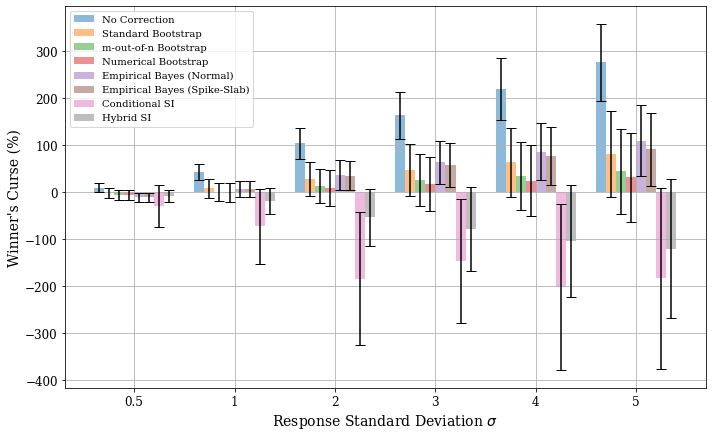

$\sigma=0.5$  $\sigma=1$  $\sigma=2$  \
No Correction                Mean            9.72       43.15      104.41   
                             Median          8.71       44.99      111.14   
                             S.E.            4.83        9.10       16.99   
Standard Bootstrap           Mean           -2.25        8.42       28.27   
                             Median         -2.79        9.37       25.23   
                             S.E.            5.29        9.99       18.92   
m-out-of-n Bootstrap         Mean           -5.39        1.13       13.49   
                             Median         -7.35        1.23        9.82   
                             S.E.            5.35       10.03       18.91   
Numerical Bootstrap          Mean           -5.42       -0.59        8.69   
                             Median         -6.46       -0.15        4.59   
                             S.E.            5.42       10.24       19.44   
Empirical Bayes (Normal)     Mean          -10.26        7.13       37.02   
                             Median        -13.15        6.62       40.89   
                             S.E.            4.86        8.84       16.01   
Empirical Bayes (Spike-Slab) Mean          -10.28        6.90       35.30   
                             Median        -13.18        6.38       39.13   
                             S.E.            4.86        8.84       16.01   
Conditional SI               Mean          -29.00      -72.66     -183.80   
                             Median         -3.18        1.10        6.27   
                             S.E.           23.00       40.48       72.34   
Hybrid SI                    Mean           -7.48      -18.41      -53.02   
                             Median         -2.34       -0.01        3.86   
                             S.E.            6.43       14.21       30.70   

                                     $\sigma=3$  $\sigma=4$  $\sigma=5$  
No Correction                Mean        163.63      219.91      276.59  
                             Median      173.55      232.55      290.69  
                             S.E.         25.20       33.47       41.72  
Standard Bootstrap           Mean         47.59       64.15       81.42  
                             Median       42.55       56.20       71.37  
                             S.E.         28.11       37.38       46.62  
m-out-of-n Bootstrap         Mean         25.35       34.52       44.26  
                             Median       15.17       21.54       27.28  
                             S.E.         28.09       37.34       46.56  
Numerical Bootstrap          Mean         17.91       24.48       31.58  
                             Median        9.30       21.03       30.03  
                             S.E.         28.89       38.43       47.93  
Empirical Bayes (Normal)     Mean         63.41       86.49      110.13  
                             Median       70.18       94.05      124.26  
                             S.E.         23.62       31.22       38.85  
Empirical Bayes (Spike-Slab) Mean         58.54       76.98       91.06  
                             Median       63.28       86.07      104.95  
                             S.E.         23.66       31.36       39.28  
Conditional SI               Mean       -146.01     -201.95     -183.15  
                             Median       22.27        9.93       35.23  
                             S.E.         66.86       90.24       98.28  
Hybrid SI                    Mean        -78.04     -103.15     -119.66  
                             Median       -8.18       -0.27      -12.08  
                             S.E.         45.76       61.03       75.48

In [29]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = response_std_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for response_std in response_std_list:
    data[response_std] = {}

    data[response_std]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[response_std][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for response_std in response_std_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[response_std][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\sigma={}$'.format(p) for p in response_std_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(response_std_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in response_std_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in response_std_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(response_std_list)), labels=response_std_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [30]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = response_std_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for response_std in response_std_list:
    data[response_std] = {}

    wc_mean = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[response_std]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[response_std][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$\sigma={response_std}$' for response_std in response_std_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(response_std_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccccc}
\toprule
 & $\sigma=0.5$ & $\sigma=1$ & $\sigma=2$ & $\sigma=3$ & $\sigma=4$ & $\sigma=5$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$9.72\%^{**}$\\ ($4.83\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$43.15\%^{***}$\\ ($9.10\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$104.41\%^{***}$\\ ($16.99\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$163.63\%^{***}$\\ ($25.20\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$219.91\%^{***}$\\ ($33.47\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$276.59\%^{***}$\\ ($41.72\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$-2.25\%$\\ ($5.29\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$8.42\%$\\ ($9.99\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$28.27\%$\\ ($18.92\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$47.59\%^{*}$\\ ($28.11\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$64.15\%^{*}$\\ ($37.38\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$81.42\%^{*}$\\ ($46.62\%$)\end{tabular} 

## $\Delta\tau / \sigma$

In [33]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Spike-Slab)'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    'hybrid_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    }, 
}

ratio_list = [0.01, 0.1, 0.5, 1, 2]
# ratio_list = [0.1, 1.0]

samp_vol_list = [1, 2, 3]


In [34]:
ratio_result_dict = {}

for ratio in ratio_list:
    for samp_vol in samp_vol_list:
        delta_tau = round(samp_vol * ratio, 2)
        print(f'\nRatio = {ratio}; Sampling Volatility = {samp_vol}; Delta tau= {delta_tau}')

        response_vol = np.sqrt(data_params['sample_size'] / 2) * samp_vol

        dgp_params['base_effects'] = [PointMass(1), PointMass(1 + delta_tau)]
        dgp_params['noise_vars'] = [UnivariateGaussian(0, std=response_vol), UnivariateGaussian(0, std=response_vol)]

        result_records = rct.repeated_experiment(
            optimization_params=optimization_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict,
            verbose=True, 
            n_jobs=-1
        )

        ratio_result_dict[(delta_tau, samp_vol, ratio)] = rct.calculate_winners_curse_measures(
            result_records=result_records, 
            optimization_params=optimization_params, 
            estimators_dict=estimators_dict, 
            data_params=data_params
        )


Ratio = 0.01; Sampling Volatility = 1; Delta tau= 0.01
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   11.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Ratio = 0.01; Sampling Volatility = 2; Delta tau= 0.02
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Ratio = 0.01; Sampling Volatility = 3; Delta tau= 0.03
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Ratio = 2; Sampling Volatility = 2; Delta tau= 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Ratio = 2; Sampling Volatility = 3; Delta tau= 6
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.4s finished


In [35]:
with open('results/ab_test_ratio.pkl', 'wb') as f:
    pickle.dump(ratio_result_dict, f)

with open('results/ab_test_ratio.pkl', 'rb') as f:
    ratio_result_dict = pickle.load(f)

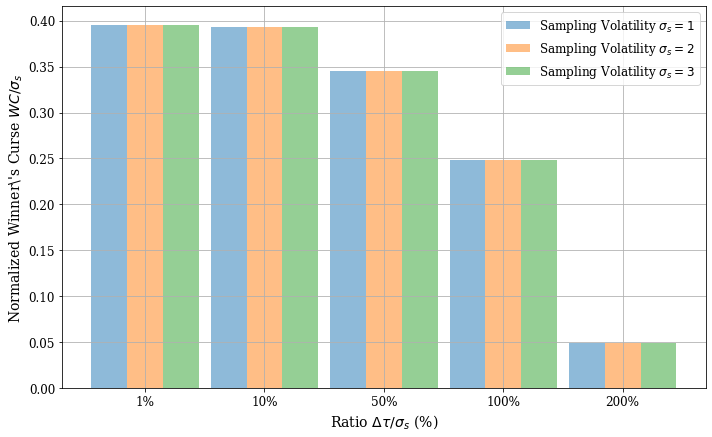

0.01  \
                                             $(\Delta\tau, \sigma_s) = (0.01, 1)$   
No Correction                         Mean                                 0.3957   
                                      Median                               0.4111   
                                      S.E.                                 0.0587   
Standard Bootstrap                    Mean                                 0.1186   
                                      Median                               0.1171   
                                      S.E.                                 0.0656   
m-out-of-n Bootstrap                  Mean                                 0.0662   
                                      Median                               0.0525   
                                      S.E.                                 0.0655   
Numerical Bootstrap                   Mean                                 0.0480   
                                      Median                               0.0523   
                                      S.E.                                 0.0675   
Empirical Bayes (Normal)              Mean                                 0.1599   
                                      Median                               0.1847   
                                      S.E.                                 0.0544   
Empirical Bayes (Spike-Slab)          Mean                                 0.1112   
                                      Median                               0.1132   
                                      S.E.                                 0.0553   
Conditional SI\n(Andrews et al. 2024) Mean                                -0.1502   
                                      Median                               0.1198   
                                      S.E.                                 0.1215   
Hybrid SI\n(Andrews et al. 2024)      Mean                                -0.1510   
                                      Median                               0.0270   
                                      S.E.                                 0.1053   

                                                                                   \
                                             $(\Delta\tau, \sigma_s) = (0.02, 2)$   
No Correction                         Mean                                 0.3957   
                                      Median                               0.4111   
                                      S.E.                                 0.1174   
Standard Bootstrap                    Mean                                 0.1186   
                                      Median                               0.1171   
                                      S.E.                                 0.1312   
m-out-of-n Bootstrap                  Mean                                 0.0662   
                                      Median                               0.0525   
                                      S.E.                                 0.1311   
Numerical Bootstrap                   Mean                                 0.0480   
                                      Median                               0.0523   
                                      S.E.                                 0.1351   
Empirical Bayes (Normal)              Mean                                 0.1599   
                                      Median                               0.1847   
                                      S.E.                                 0.1089   
Empirical Bayes (Spike-Slab)          Mean                                 0.0779   
                                      Median                               0.0796   
                                      S.E.                                 0.1118   
Conditional SI\n(Andrews et al. 2024) Mean                                 0.0464   
                                      Median                               0.1981

In [36]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = ratio_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau, samp_vol, ratio = key

    data[(delta_tau, samp_vol)] = {}

    data[(delta_tau, samp_vol)]['No Correction'] = {
        'Mean': result_dict[key][f'{optimizer_key}_nc_wc_avg'] / samp_vol, 
        'Median': np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']) / samp_vol, 
        'S.E.': result_dict[key][f'{optimizer_key}_nc_wc_se'], 
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / samp_vol
        median_wc = np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr']) / samp_vol
        se_wc = result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[(delta_tau, samp_vol)][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (ratio, '$(\Delta\tau, \sigma_s) = ({}, {})$'.format(delta_tau, samp_vol))
    for delta_tau, samp_vol, ratio in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for delta_tau, samp_vol, _ in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[(delta_tau, samp_vol)][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(ratio_list))
bar_width = 0.3 * len(samp_vol_list)

for idx, samp_vol in enumerate(samp_vol_list):
    bar_values = [data[(dt, vol)]['No Correction']['Mean'] for dt, vol, _ in result_dict.keys() if vol == samp_vol]
    bar_errors = [1.96 * data[(dt, vol)]['No Correction']['S.E.'] for dt, vol, _ in result_dict.keys() if vol == samp_vol]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / len(samp_vol_list) + bar_width / 2 / len(samp_vol_list), 
        bar_values, 
        # yerr=bar_errors, 
        capsize=5, alpha=0.5, width=bar_width / len(samp_vol_list),
        label=r'Sampling Volatility $\sigma_s={}$'.format(samp_vol)
    )

ax.set_xlabel(r'Ratio $\Delta\tau / \sigma_s$ (%)', fontsize=axis_label_size)
ax.set_ylabel(r'Normalized Winner\'s Curse $WC / \sigma_s$', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(ratio_list)), 
    labels=[f'{item:.0%}' for item in ratio_list], 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=tick_label_size)
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(4)

In [37]:
print(wc_stats_df[[0.1, 1]].map(lambda x: f'{x:.4f}').style.to_latex())

\begin{tabular}{llllllll}
 &  & \multicolumn{3}{r}{0.100000} & \multicolumn{3}{r}{1.000000} \\
 &  & $(\Delta	au, \sigma_s) = (0.1, 1)$ & $(\Delta	au, \sigma_s) = (0.2, 2)$ & $(\Delta	au, \sigma_s) = (0.3, 3)$ & $(\Delta	au, \sigma_s) = (1, 1)$ & $(\Delta	au, \sigma_s) = (2, 2)$ & $(\Delta	au, \sigma_s) = (3, 3)$ \\
\multirow[c]{3}{*}{No Correction} & Mean & 0.3932 & 0.3932 & 0.3932 & 0.2480 & 0.2480 & 0.2480 \\
 & Median & 0.4111 & 0.4111 & 0.4111 & 0.2617 & 0.2617 & 0.2617 \\
 & S.E. & 0.0588 & 0.1177 & 0.1765 & 0.0665 & 0.1331 & 0.1996 \\
\multirow[c]{3}{*}{Standard Bootstrap} & Mean & 0.1164 & 0.1164 & 0.1099 & 0.0312 & 0.0312 & 0.0509 \\
 & Median & 0.1048 & 0.1048 & 0.1043 & 0.0241 & 0.0241 & 0.0510 \\
 & S.E. & 0.0658 & 0.1315 & 0.1886 & 0.0724 & 0.1449 & 0.2014 \\
\multirow[c]{3}{*}{m-out-of-n Bootstrap} & Mean & 0.0640 & 0.0640 & 0.0575 & -0.0186 & -0.0186 & 0.0081 \\
 & Median & 0.0403 & 0.0403 & 0.0399 & -0.0251 & -0.0251 & 0.0066 \\
 & S.E. & 0.0657 & 0.1314 & 0.1884 & 0.07

In [38]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = ratio_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau, samp_vol, ratio = key

    data[(delta_tau, samp_vol)] = {}

    wc_mean = result_dict[key][f'{optimizer_key}_nc_wc_avg'] / samp_vol
    wc_se = result_dict[key][f'{optimizer_key}_nc_wc_se'] / samp_vol
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[(delta_tau, samp_vol)]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.4f}" + sig_level + f"$\\\\ (${wc_se:.4f}$)" + "\end{tabular}"

    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / samp_vol
        wc_se = result_dict[key][f'{optimizer_key}_{est_key}_wc_se'] / samp_vol
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[(delta_tau, samp_vol)][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.4f}" + sig_level + f"$\\\\ (${wc_se:.4f}$)" + "\end{tabular}"

# Create the MultiIndex DataFrame
col_index = pd.MultiIndex.from_tuples([
    (f'{ratio:.2f}', '$(\Delta\\tau, \sigma_s) = ({:.2f}, {:.2f})$'.format(delta_tau, samp_vol))
    for delta_tau, samp_vol, ratio in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for delta_tau, samp_vol, _ in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
            column_data.append(data[(delta_tau, samp_vol)][est_name])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
latex_df = pd.DataFrame(
    np.array(df_data).T,
    index=estimator_names,
    columns=col_index
)[['0.10', '1.00']]
print(latex_df.style.to_latex(
    column_format='c' * 2 * 3, 
    hrules=True
))


\begin{tabular}{cccccc}
\toprule
 & \multicolumn{3}{r}{0.10} & \multicolumn{3}{r}{1.00} \\
 & $(\Delta\tau, \sigma_s) = (0.10, 1.00)$ & $(\Delta\tau, \sigma_s) = (0.20, 2.00)$ & $(\Delta\tau, \sigma_s) = (0.30, 3.00)$ & $(\Delta\tau, \sigma_s) = (1.00, 1.00)$ & $(\Delta\tau, \sigma_s) = (2.00, 2.00)$ & $(\Delta\tau, \sigma_s) = (3.00, 3.00)$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$0.3932^{***}$\\ ($0.0588$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.3932^{***}$\\ ($0.0588$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.3932^{***}$\\ ($0.0588$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.2480^{***}$\\ ($0.0665$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.2480^{***}$\\ ($0.0665$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.2480^{***}$\\ ($0.0665$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.1164^{*}$\\ ($0.0658$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.1164^{*}$\\ ($0.0658$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.1099^{*}$\\ ($0.0629

## Noise distribution

In [183]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.05)],
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    # }, 
}

noise_dstn_dict = {
    'Normal(0, 1)': UnivariateGaussian(0, std=1),
    'Uniform($-\sqrt{3}$, $-\sqrt{3}$)': Uniform(-3**0.5, 3**0.5),
    r'Laplace(0, $1/\sqrt{2}$)': Laplace(0, 1 / np.sqrt(2)), 
    r'Logistic(0, $\sqrt{3} / \pi$)': Logistic(0, np.sqrt(3) / np.pi), 
}

In [184]:
noise_dstn_result_dict = {noise_dstn: None for noise_dstn in noise_dstn_dict.keys()}

for noise_key, noise_dstn in noise_dstn_dict.items():
    print(f'\nNoise Distribution = {noise_key}')
    
    dgp_params['noise_vars'] = [noise_dstn, noise_dstn]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    noise_dstn_result_dict[noise_key] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Noise Distribution = Normal(0, 1)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:    9.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   10.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Noise Distribution = Uniform($-\sqrt{3}$, $-\sqrt{3}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Noise Distribution = Laplace(0, $1/\sqrt{2}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Noise Distribution = Logistic(0, $\sqrt{3} / \pi$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.6s finished


In [185]:
with open('results/ab_test_noise_dstn.pkl', 'wb') as f:
    pickle.dump(noise_dstn_result_dict, f)

with open('results/ab_test_noise_dstn.pkl', 'rb') as f:
    noise_dstn_result_dict = pickle.load(f)

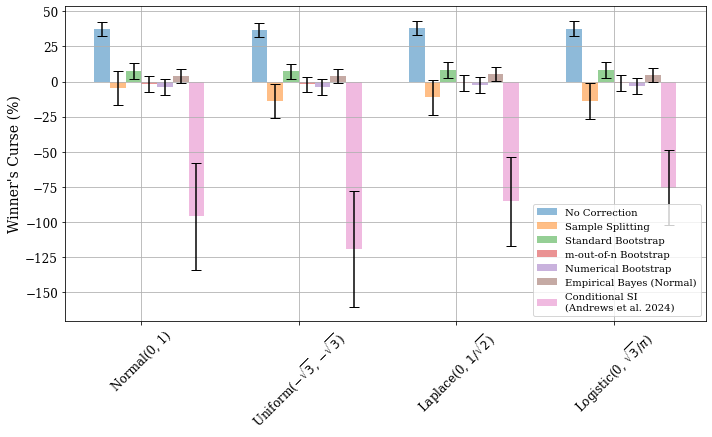

Normal(0, 1)  \
No Correction                         Mean           37.28   
                                      Median         36.58   
                                      S.E.            2.59   
Sample Splitting                      Mean           -4.72   
                                      Median          2.89   
                                      S.E.            6.28   
Standard Bootstrap                    Mean            7.42   
                                      Median          5.58   
                                      S.E.            2.85   
m-out-of-n Bootstrap                  Mean           -1.56   
                                      Median         -3.47   
                                      S.E.            2.87   
Numerical Bootstrap                   Mean           -3.77   
                                      Median         -8.08   
                                      S.E.            2.95   
Empirical Bayes (Normal)              Mean            4.12   
                                      Median          2.66   
                                      S.E.            2.52   
Conditional SI\n(Andrews et al. 2024) Mean          -96.01   
                                      Median          2.38   
                                      S.E.           19.55   
Sample Splitting                      Mean           -4.72   
                                      Median          2.89   
                                      S.E.            6.28   

                                              Uniform($-\sqrt{3}$, $-\sqrt{3}$)  \
No Correction                         Mean                                36.90   
                                      Median                              37.01   
                                      S.E.                                 2.52   
Sample Splitting                      Mean                               -13.67   
                                      Median                              -2.74   
                                      S.E.                                 6.15   
Standard Bootstrap                    Mean                                 7.23   
                                      Median                               8.64   
                                      S.E.                                 2.75   
m-out-of-n Bootstrap                  Mean                                -2.13   
                                      Median                              -2.47   
                                      S.E.                                 2.78   
Numerical Bootstrap                   Mean                                -3.95   
                                      Median                              -2.62   
                                      S.E.                                 2.85   
Empirical Bayes (Normal)              Mean                                 3.77   
                                      Median                               1.42   
                                      S.E.                                 2.46   
Conditional SI\n(Andrews et al. 2024) Mean                              -119.01   
                                      Median                               2.65   
                                      S.E.                                21.08   
Sample Splitting                      Mean                               -13.67   
                                      Median                              -2.74   
                                      S.E.                                 6.15   

                                              Laplace(0, $1/\sqrt{2}$)  \
No Correction                         Mean                       38.13   
                                      Median                     37.58   
                                      S.E.                        2.63   
Sample Splitting                      Mean                      -11.32   
                                      Median     

In [186]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = noise_dstn_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for noise_dstn in noise_dstn_dict.keys():
    data[noise_dstn] = {}

    data[noise_dstn]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[noise_dstn][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

    # sample splitting
    ss_wc_avg = 100 / delta_tau * np.mean(result_dict[noise_dstn]['rank_and_select_sample_splitting_val_est_arr'] - result_dict[noise_dstn]['rank_and_select_nc_val_true_arr'])
    ss_wc_se = 100 / delta_tau * np.std(result_dict[noise_dstn]['rank_and_select_sample_splitting_val_est_arr'] - result_dict[noise_dstn]['rank_and_select_nc_val_true_arr']) / np.sqrt(data_params['sample_size'])
    ss_wc_median = 100 / delta_tau * np.median(result_dict[noise_dstn]['rank_and_select_sample_splitting_val_est_arr'] - result_dict[noise_dstn]['rank_and_select_nc_val_true_arr'])
    data[noise_dstn]['Sample Splitting'] = {
        'Mean': ss_wc_avg, 'Median': ss_wc_median, 'S.E.': ss_wc_se
    }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names + ['Sample Splitting'], ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for noise_dstn in noise_dstn_dict.keys():
    column_data = []
    for est_name in estimator_names + ['Sample Splitting']:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[noise_dstn][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=list(noise_dstn_dict.keys())
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(noise_dstn_dict.keys()))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in noise_dstn_dict.keys()]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in noise_dstn_dict.keys()]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(noise_dstn_dict.keys())), 
    labels=noise_dstn_dict.keys(), 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [187]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = noise_dstn_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean
# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for noise_dstn in noise_dstn_dict.keys():
    data[noise_dstn] = {}

    wc_mean = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[noise_dstn]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[noise_dstn][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = list(noise_dstn_dict.keys())
print(latex_df.style.to_latex(
    column_format='c' * (len(noise_dstn_dict) + 1), 
    hrules=True
))

\begin{tabular}{ccccc}
\toprule
 & Normal(0, 1) & Uniform($-\sqrt{3}$, $-\sqrt{3}$) & Laplace(0, $1/\sqrt{2}$) & Logistic(0, $\sqrt{3} / \pi$) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$37.28\%^{***}$\\ ($2.59\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$36.90\%^{***}$\\ ($2.52\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$38.13\%^{***}$\\ ($2.63\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$37.72\%^{***}$\\ ($2.60\%$)\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}$-4.72\%$\\ ($4.44\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-13.67\%^{***}$\\ ($4.35\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-11.32\%^{**}$\\ ($4.52\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-13.89\%^{***}$\\ ($4.51\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$7.42\%^{***}$\\ ($2.85\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$7.23\%^{***}$\\ ($2.75\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$8.41\%^{***}$\\ ($2.89\%$)\end{tabular} & \begin{tabula

## Number of Treatments

In [377]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'response_type': 'continuous', 
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    # 'eb_tweedies': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'tweedies', 'dof': 3, 'bin_width': 0.2, 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Tweedies)'
    # }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

n_treatments_list = [2, 4, 6, 8, 10]
delta_tau = 0.0

In [378]:
n_treatments_result_dict = {n_treatments: None for n_treatments in n_treatments_list}

for n_treatments in n_treatments_list:
    print(f'\nNumber of Treatments = {n_treatments}')
    
    dgp_params['base_effects'] = [PointMass(1 + i * delta_tau) for i in range(n_treatments)]
    dgp_params['noise_vars'] = [UnivariateGaussian(0, std=1) for _ in range(n_treatments)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    n_treatments_result_dict[n_treatments] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Number of Treatments = 2
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   11.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   12.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Number of Treatments = 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   10.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Number of Treatments = 6
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   13.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   15.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Number of Treatments = 8
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   15.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   17.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Number of Treatments = 10
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   17.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   20.3s finished


In [381]:
with open('results/ab_test_n_treatments.pkl', 'wb') as f:
    pickle.dump(n_treatments_result_dict, f)

with open('results/ab_test_n_treatments.pkl', 'rb') as f:
    n_treatments_result_dict = pickle.load(f)

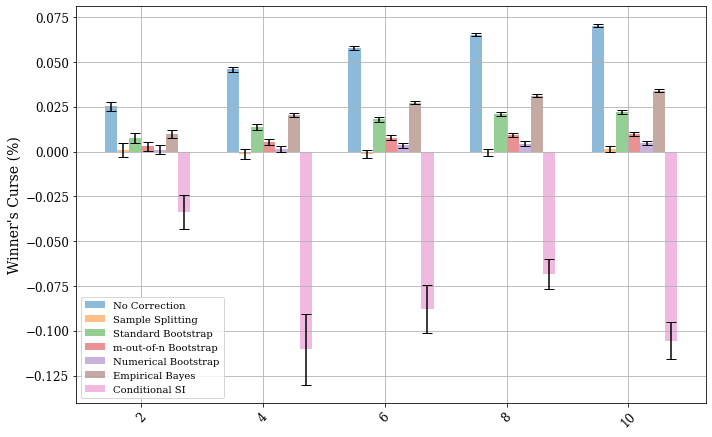

2       4       6       8       10
No Correction        Mean    0.0252  0.0459  0.0578  0.0653  0.0701
                     Median  0.0242  0.0431  0.0571  0.0640  0.0689
                     S.E.    0.0012  0.0007  0.0005  0.0004  0.0004
Sample Splitting     Mean    0.0009 -0.0012 -0.0016 -0.0007  0.0013
                     Median  0.0024  0.0007 -0.0007 -0.0022 -0.0004
                     S.E.    0.0020  0.0014  0.0011  0.0010  0.0009
Standard Bootstrap   Mean    0.0076  0.0135  0.0180  0.0207  0.0220
                     Median  0.0044  0.0113  0.0151  0.0180  0.0188
                     S.E.    0.0013  0.0008  0.0007  0.0006  0.0005
m-out-of-n Bootstrap Mean    0.0029  0.0051  0.0077  0.0092  0.0097
                     Median -0.0002  0.0028  0.0046  0.0063  0.0078
                     S.E.    0.0013  0.0008  0.0007  0.0006  0.0005
Numerical Bootstrap  Mean    0.0010  0.0016  0.0035  0.0045  0.0046
                     Median -0.0023 -0.0010 -0.0004  0.0009  0.0018
                     S.E.    0.0014  0.0009  0.0007  0.0006  0.0005
Empirical Bayes      Mean    0.0099  0.0204  0.0273  0.0313  0.0340
                     Median  0.0083  0.0168  0.0252  0.0296  0.0329
                     S.E.    0.0011  0.0006  0.0005  0.0004  0.0003
Conditional SI       Mean   -0.0338 -0.1104 -0.0877 -0.0681 -0.1055
                     Median  0.0022 -0.0003  0.0059  0.0070  0.0002
                     S.E.    0.0049  0.0101  0.0069  0.0043  0.0052

In [382]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = n_treatments_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each
for n_treatments in n_treatments_list:
    data[n_treatments] = {}

    data[n_treatments]['No Correction'] = {
        'Mean': result_dict[n_treatments][f'{optimizer_key}_nc_wc_avg'],
        'Median': np.nanmedian(result_dict[n_treatments][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': result_dict[n_treatments][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = np.nanmedian(result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[n_treatments][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for n_treatments in n_treatments_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[n_treatments][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=n_treatments_list
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(n_treatments_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in n_treatments_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in n_treatments_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(n_treatments_list)), 
    labels=n_treatments_list, 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(4)

In [384]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = n_treatments_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for n_treatments in n_treatments_list:
    data[n_treatments] = {}

    wc_mean = result_dict[n_treatments][f'{optimizer_key}_nc_wc_avg']
    wc_se = result_dict[n_treatments][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[n_treatments]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.4f}" + sig_level + f"$\\\\ (${wc_se:.4f}$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[n_treatments][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.4f}" + sig_level + f"$\\\\ (${wc_se:.4f}$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [n_treatments for n_treatments in n_treatments_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(n_treatments_list) + 1), 
    hrules=True
))

\begin{tabular}{cccccc}
\toprule
 & 2 & 4 & 6 & 8 & 10 \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$0.0252^{***}$\\ ($0.0012$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0459^{***}$\\ ($0.0007$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0578^{***}$\\ ($0.0005$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0653^{***}$\\ ($0.0004$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0701^{***}$\\ ($0.0004$)\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}$0.0009$\\ ($0.0020$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.0012$\\ ($0.0014$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.0016$\\ ($0.0011$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.0007$\\ ($0.0010$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0013$\\ ($0.0009$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.0076^{***}$\\ ($0.0013$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0135^{***}$\\ ($0.0008$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0180^{***}$\\ ($0.0007$)\end{tab

# Bernoulli Response

In [234]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'response_type': 'bernoulli', 
    'dgp_seed': 0
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Spike-Slab)'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    'hybrid_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    }, 
}

In [235]:
bernoulli_te_list = [
    # (0.1, 0.11), (0.2, 0.21), (0.3, 0.31), (0.1, 0.15), (0.2, 0.25), (0.3, 0.35)
    (0.1, 0.105), (0.2, 0.205), (0.3, 0.305), (0.1, 0.11), (0.2, 0.21), (0.3, 0.31)
]

bernoulli_te_result_dict = {bernoulli_te: None for bernoulli_te in bernoulli_te_list}

for te_tuple in bernoulli_te_list:
    print(f'\n(tau_1, tau_2)= {te_tuple}')
    
    dgp_params['base_effects'] = [PointMass(te_tuple[0]), PointMass(te_tuple[1])]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    bernoulli_te_result_dict[te_tuple] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params, 
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


(tau_1, tau_2)= (0.1, 0.105)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    9.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



(tau_1, tau_2)= (0.2, 0.205)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



(tau_1, tau_2)= (0.3, 0.305)
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



(tau_1, tau_2)= (0.2, 0.21)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



(tau_1, tau_2)= (0.3, 0.31)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    6.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   10.1s finished


In [236]:
with open('results/ab_test_bernoulli_delta_tau.pkl', 'wb') as f:
    pickle.dump(bernoulli_te_result_dict, f)

with open('results/ab_test_bernoulli_delta_tau.pkl', 'rb') as f:
    bernoulli_te_result_dict = pickle.load(f)

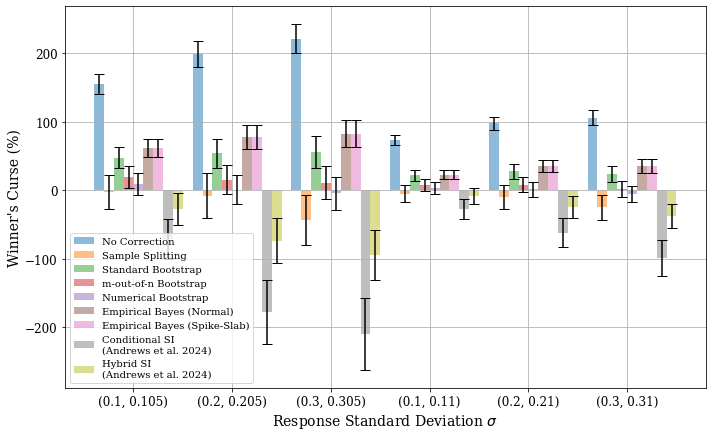

$\Delta\tau = 0.005$  \
                                             $(\tau_1, \tau_2)$ = (0.1, 0.105)   
No Correction                         Mean                              155.68   
                                      Median                            140.00   
                                      S.E.                                7.38   
Sample Splitting                      Mean                               -2.64   
                                      Median                            -20.00   
                                      S.E.                               12.57   
Standard Bootstrap                    Mean                               47.83   
                                      Median                             32.80   
                                      S.E.                                8.07   
m-out-of-n Bootstrap                  Mean                               19.84   
                                      Median                              5.20   
                                      S.E.                                8.10   
Numerical Bootstrap                   Mean                                9.15   
                                      Median                             -7.05   
                                      S.E.                                8.33   
Empirical Bayes (Normal)              Mean                               62.05   
                                      Median                             51.17   
                                      S.E.                                6.84   
Empirical Bayes (Spike-Slab)          Mean                               62.04   
                                      Median                             51.15   
                                      S.E.                                6.84   
Conditional SI\n(Andrews et al. 2024) Mean                              -70.72   
                                      Median                             27.73   
                                      S.E.                               14.72   
Hybrid SI\n(Andrews et al. 2024)      Mean                              -27.32   
                                      Median                             31.10   
                                      S.E.                               11.93   

                                                                                \
                                             $(\tau_1, \tau_2)$ = (0.2, 0.205)   
No Correction                         Mean                              198.52   
                                      Median                            180.00   
                                      S.E.                                9.80   
Sample Splitting                      Mean                               -7.64   
                                      Median                            -20.00   
                                      S.E.                               17.00   
Standard Bootstrap                    Mean                               54.28   
                                      Median                             38.44   
                                      S.E.                               10.76   
m-out-of-n Bootstrap                  Mean                               15.65   
                                      Median                             -2.03   
                                      S.E.                               10.76   
Numerical Bootstrap                   Mean                                1.14   
                                      Median                            -13.98   
                                      S.E.                               11.09   
Empirical Bayes (Normal)              Mean                               77.64   
                                      Median                             61.20   
                                      S.E.                                9.13   
Empirical Bayes (Spike-Slab)          M

In [239]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = bernoulli_te_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    data[key]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[key][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\tau = {np.round(key[1] - key[0], 4)}$', '$(\tau_1, \tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[key][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(bernoulli_te_list))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in bernoulli_te_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in bernoulli_te_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(bernoulli_te_list)), labels=bernoulli_te_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [243]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = bernoulli_te_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    wc_mean = result_dict[key][f'{optimizer_key}_nc_wc_avg'] / delta_tau * 100
    wc_se = result_dict[key][f'{optimizer_key}_nc_wc_se'] / delta_tau * 100
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[key]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / delta_tau * 100
        wc_se = result_dict[key][f'{optimizer_key}_{est_key}_wc_se'] / delta_tau * 100
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[key][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

# Create the MultiIndex DataFrame
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\\tau = {np.round(key[1] - key[0], 4)}$', '$(\\tau_1, \\tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
            column_data.append(data[key][est_name])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
latex_df = pd.DataFrame(
    np.array(df_data).T,
    index=estimator_names,
    columns=col_index
)[['$\Delta\\tau = 0.005$', '$\Delta\\tau = 0.01$']]
print(latex_df.style.to_latex(
    column_format='c' * (2 * 3 + 1), 
    hrules=True
))


\begin{tabular}{ccccccc}
\toprule
 & \multicolumn{3}{r}{$\Delta\tau = 0.005$} & \multicolumn{3}{r}{$\Delta\tau = 0.01$} \\
 & $(\tau_1, \tau_2)$ = (0.1, 0.105) & $(\tau_1, \tau_2)$ = (0.2, 0.205) & $(\tau_1, \tau_2)$ = (0.3, 0.305) & $(\tau_1, \tau_2)$ = (0.1, 0.11) & $(\tau_1, \tau_2)$ = (0.2, 0.21) & $(\tau_1, \tau_2)$ = (0.3, 0.31) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$155.68\%^{***}$\\ ($7.38$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$198.52\%^{***}$\\ ($9.80$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$221.48\%^{***}$\\ ($10.99$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$73.52\%^{***}$\\ ($3.86$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$97.68\%^{***}$\\ ($5.02$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$105.96\%^{***}$\\ ($5.54$)\%\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}$-2.64\%$\\ ($12.57$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-7.64\%$\\ ($17.00$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-43.08\%^{**}$\\ ($18.43

In [244]:
optimizer_key = 'rank_and_select'
wc_measures_dict = bernoulli_te_result_dict[(0.3, 0.31)]


nc_val_true_avg  = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
nc_val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
clairvoyant_val = 0.31
policy_comp_dict = {
    'Clairvoyant Policy': {'Policy Value': f"{clairvoyant_val:.4f}"}, 
    'Focal Policy': {'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${nc_val_true_avg:.4f}" + f"$\\\\ (${nc_val_true_se:.4f}$)" + "\end{tabular}"},
}

ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
random_val = 0.305
policy_comp_dict.update({
    'Sample Splitting': {'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_true_avg:.4f}" + f"$\\\\ (${ss_val_true_se:.4f}$)" + "\end{tabular}"}, 
    'Random Guessing': {'Policy Value': f'{random_val:.4f}'},
})

policy_comp_df = pd.DataFrame(policy_comp_dict).T
policy_comp_df
# print(policy_comp_df.style.to_latex(
#     column_format='cc',  
#     hrules=True
# ))

,Policy Value
Clairvoyant Policy,0.3100
Focal Policy,\begin{tabular}[c]{@{}c@{}}$0.3062$\\ ($0.0002...
Sample Splitting,\begin{tabular}[c]{@{}c@{}}$0.3056$\\ ($0.0002...
Random Guessing,0.3050


## Sample Size

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(0.1), PointMass(0.105)],
    'response_type': 'bernoulli',
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

sample_size_list = [50, 100, 500, 1000, 2500, 5000, 35000]


In [72]:
bernoulli_sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    bernoulli_sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


Sample Size = 30000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.1s finished


In [45]:
with open('results/ab_test_bernoulli_sample_size.pkl', 'wb') as f:
    pickle.dump(bernoulli_sample_size_result_dict, f)

with open('results/ab_test_bernoulli_sample_size.pkl', 'rb') as f:
    bernoulli_sample_size_result_dict = pickle.load(f)

ZeroDivisionError: float division by zero

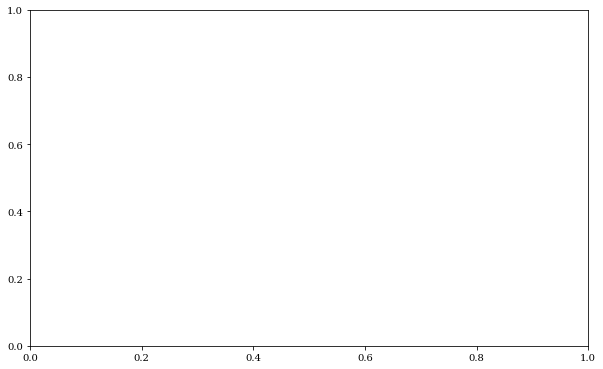

In [69]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = bernoulli_sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [73]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = bernoulli_sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[sample_size]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[sample_size][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$N={sample_size}$' for sample_size in sample_size_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(sample_size_list) + 1), 
    hrules=True
))

\begin{tabular}{cc}
\toprule
 & $N=30000$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$0.07\%$\\ ($0.15\%$)\end{tabular} \\
\bottomrule
\end{tabular}



# Logit Response

In [54]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'response_type': 'logit', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Spike-Slab)'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    'hybrid_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI'
    }, 
}

In [55]:
logit_te_list = [
    (0.1, 0.11), (0.2, 0.21), (0.3, 0.31), (0.1, 0.15), (0.2, 0.25), (0.3, 0.35)
]

logit_te_result_dict = {logit_te: None for logit_te in logit_te_list}

for te_tuple in logit_te_list:
    print(f'\n(tau_1, tau_2)= {te_tuple}')
    
    dgp_params['base_effects'] = [PointMass(te_tuple[0]),PointMass(te_tuple[1])]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    logit_te_result_dict[te_tuple] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params, 
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


(tau_1, tau_2)= (0.1, 0.11)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   16.6s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   37.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   44.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



(tau_1, tau_2)= (0.2, 0.21)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   17.0s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   38.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   48.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



(tau_1, tau_2)= (0.3, 0.31)
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   17.4s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   43.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   49.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



(tau_1, tau_2)= (0.2, 0.25)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   17.7s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   39.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   45.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



(tau_1, tau_2)= (0.3, 0.35)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   16.7s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   40.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   45.9s finished


In [56]:
with open('results/ab_test_logit_delta_tau.pkl', 'wb') as f:
    pickle.dump(logit_te_result_dict, f)

with open('results/ab_test_logit_delta_tau.pkl', 'rb') as f:
    logit_te_result_dict = pickle.load(f)

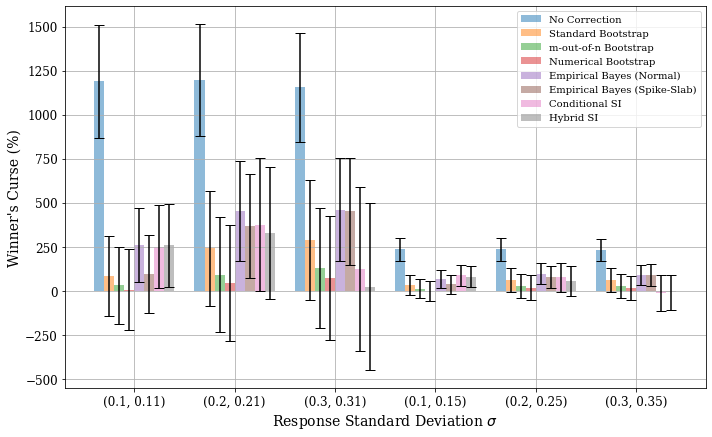

$\Delta\tau = 0.01$  \
                                    $(\tau_1, \tau_2)$ = (0.1, 0.11)   
No Correction                Mean                            1189.36   
                             Median                          1311.62   
                             S.E.                             162.86   
Standard Bootstrap           Mean                              86.10   
                             Median                           150.82   
                             S.E.                             115.90   
m-out-of-n Bootstrap         Mean                              31.18   
                             Median                            99.39   
                             S.E.                             112.39   
Numerical Bootstrap          Mean                               6.78   
                             Median                            83.26   
                             S.E.                             116.99   
Empirical Bayes (Normal)     Mean                             261.23   
                             Median                           325.05   
                             S.E.                             107.22   
Empirical Bayes (Spike-Slab) Mean                              96.69   
                             Median                           101.93   
                             S.E.                             112.86   
Conditional SI               Mean                             251.29   
                             Median                           409.02   
                             S.E.                             121.18   
Hybrid SI                    Mean                             258.53   
                             Median                           416.64   
                             S.E.                             120.68   

                                                                      \
                                    $(\tau_1, \tau_2)$ = (0.2, 0.21)   
No Correction                Mean                            1197.56   
                             Median                          1177.73   
                             S.E.                             162.47   
Standard Bootstrap           Mean                             240.84   
                             Median                           284.38   
                             S.E.                             165.80   
m-out-of-n Bootstrap         Mean                              92.34   
                             Median                           123.66   
                             S.E.                             166.01   
Numerical Bootstrap          Mean                              43.39   
                             Median                            42.39   
                             S.E.                             167.88   
Empirical Bayes (Normal)     Mean                             451.66   
                             Median                           428.01   
                             S.E.                             144.53   
Empirical Bayes (Spike-Slab) Mean                             368.28   
                             Median                           390.35   
                             S.E.                             151.03   
Conditional SI               Mean                             375.87   
                             Median                           555.36   
                             S.E.                             192.01   
Hybrid SI                    Mean                             327.61   
                             Median                           461.50   
                             S.E.                             191.81   

                                                                      \
                                    $(\tau_1, \tau_2)$ = (0.3, 0.31)   
No Correction                Mean                            1155.45   
                             Median                          1054.65   
               

In [57]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = logit_te_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    data[key]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[key][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\tau = {np.round(key[1] - key[0], 2)}$', '$(\tau_1, \tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[key][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(logit_te_list))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in logit_te_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in logit_te_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(logit_te_list)), labels=logit_te_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [58]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = logit_te_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    wc_mean = result_dict[key][f'{optimizer_key}_nc_wc_avg'] / delta_tau * 100
    wc_se = result_dict[key][f'{optimizer_key}_nc_wc_se'] / delta_tau * 100
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[key]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / delta_tau * 100
        wc_se = result_dict[key][f'{optimizer_key}_{est_key}_wc_se'] / delta_tau * 100
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[key][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

# Create the MultiIndex DataFrame
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\\tau = {np.round(key[1] - key[0], 2)}$', '$(\\tau_1, \\tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
            column_data.append(data[key][est_name])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
latex_df = pd.DataFrame(
    np.array(df_data).T,
    index=estimator_names,
    columns=col_index
)[['$\Delta\\tau = 0.01$', '$\Delta\\tau = 0.05$']]
print(latex_df.style.to_latex(
    column_format='c' * (2 * 3 + 1), 
    hrules=True
))


\begin{tabular}{ccccccc}
\toprule
 & \multicolumn{3}{r}{$\Delta\tau = 0.01$} & \multicolumn{3}{r}{$\Delta\tau = 0.05$} \\
 & $(\tau_1, \tau_2)$ = (0.1, 0.11) & $(\tau_1, \tau_2)$ = (0.2, 0.21) & $(\tau_1, \tau_2)$ = (0.3, 0.31) & $(\tau_1, \tau_2)$ = (0.1, 0.15) & $(\tau_1, \tau_2)$ = (0.2, 0.25) & $(\tau_1, \tau_2)$ = (0.3, 0.35) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$1189.36\%^{***}$\\ ($162.86$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1197.56\%^{***}$\\ ($162.47$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1155.45\%^{***}$\\ ($158.40$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$234.63\%^{***}$\\ ($32.74$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$235.64\%^{***}$\\ ($32.88$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$231.63\%^{***}$\\ ($31.67$)\%\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$86.10\%$\\ ($115.90$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$240.84\%$\\ ($165.80$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$288.69\%^{

## Sample Size

In [449]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(np.log(1 / 9)), PointMass(np.log(11 / 89))],
    'response_type': 'logit',
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Spike-Slab)'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    'hybrid_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI'
    }, 
}

# sample_size_list = [50, 100, 500, 1000, 2500, 5000]
sample_size_list = [500]

In [450]:
logit_sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    logit_sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


Sample Size = 500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   31.2s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  1.3min finished
/Users/iamsikun/Desktop/research/winners-curse/core/rct.py:473: RuntimeWarning: Mean of empty slice
  f'{optimizer}_{estimator}_val_est_avg': np.nanmean(temp_val_est_arr),
/Users/iamsikun/miniforge3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/iamsikun/Desktop/research/winners-curse/core/rct.py:475: RuntimeWarning: Mean of empty slice
  f'{optimizer}_{estimator}_wc_avg': np.nanmean(temp_wc_arr),


In [299]:
# with open('results/ab_test_logit_sample_size.pkl', 'wb') as f:
#     pickle.dump(logit_sample_size_result_dict, f)

with open('results/ab_test_logit_sample_size.pkl', 'rb') as f:
    logit_sample_size_result_dict = pickle.load(f)

/Users/iamsikun/miniforge3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


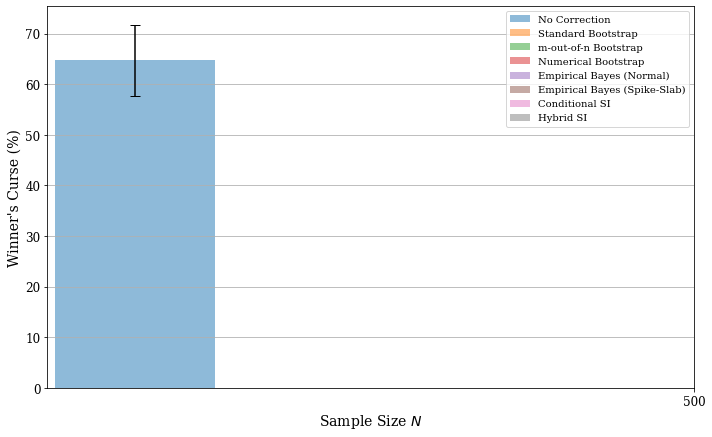

$N=500$
No Correction                Mean      64.69
                             Median    56.23
                             S.E.       3.61
Standard Bootstrap           Mean        NaN
                             Median      NaN
                             S.E.        NaN
m-out-of-n Bootstrap         Mean        NaN
                             Median      NaN
                             S.E.        NaN
Numerical Bootstrap          Mean        NaN
                             Median      NaN
                             S.E.        NaN
Empirical Bayes (Normal)     Mean        NaN
                             Median      NaN
                             S.E.        NaN
Empirical Bayes (Spike-Slab) Mean        NaN
                             Median      NaN
                             S.E.        NaN
Conditional SI               Mean        NaN
                             Median      NaN
                             S.E.        NaN
Hybrid SI                    Mean        NaN
                             Median      NaN
                             S.E.        NaN

In [451]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = logit_sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [452]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = logit_sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[sample_size]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[sample_size][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$N={sample_size}$' for sample_size in sample_size_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(sample_size_list) + 1), 
    hrules=True
))

\begin{tabular}{cc}
\toprule
 & $N=500$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$64.69\%^{***}$\\ ($3.61\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} \\
Numerical Bootstrap & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} \\
Empirical Bayes (Normal) & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} \\
Empirical Bayes (Spike-Slab) & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} \\
Conditional SI & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} \\
Hybrid SI & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} \\
\bottomrule
\end{tabular}



# Sketch

In [20]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
}

sample_size_list = [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000, 5000]

In [21]:
dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'response_type': 'continuous',
    'dgp_seed': 0
}

cont_sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=False, 
        n_jobs=-1
    )

    # truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    cont_sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True,  # remove outliers due to numerical instability
    )

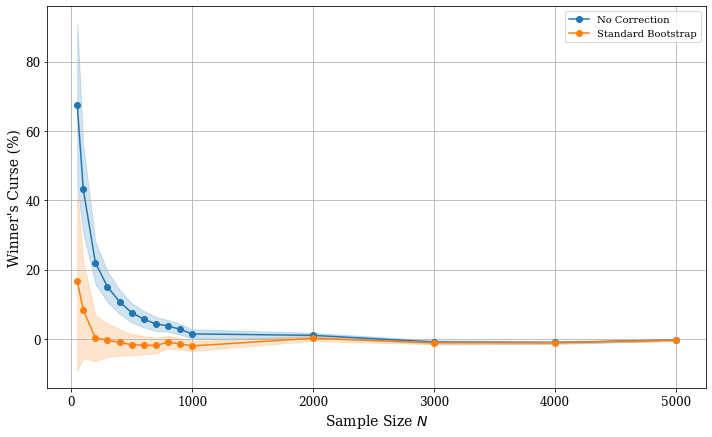

In [22]:
cont_nc_wc_avg = np.array([result_dict['rank_and_select_nc_wc_avg'] for result_dict in cont_sample_size_result_dict.values()]) / 0.1 * 100
cont_nc_wc_se = np.array([result_dict['rank_and_select_nc_wc_se'] for result_dict in cont_sample_size_result_dict.values()]) / 0.1 * 100

cont_boot_wc_avg = np.array([result_dict['rank_and_select_standard_bootstrap_wc_avg'] for result_dict in cont_sample_size_result_dict.values()]) / 0.1 * 100
cont_boot_wc_se = np.array([result_dict['rank_and_select_standard_bootstrap_wc_se'] for result_dict in cont_sample_size_result_dict.values()]) / 0.1 * 100

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.plot(sample_size_list, cont_nc_wc_avg, label='No Correction', color='C0', marker='o')
ax.fill_between(
    sample_size_list, 
    cont_nc_wc_avg - 1.96 * cont_nc_wc_se, 
    cont_nc_wc_avg + 1.96 * cont_nc_wc_se, 
    alpha=0.2, color='C0'
)
ax.plot(sample_size_list, cont_boot_wc_avg, label='Standard Bootstrap', color='C1', marker='o')
ax.fill_between(
    sample_size_list, 
    cont_boot_wc_avg - 1.96 * cont_boot_wc_se, 
    cont_boot_wc_avg + 1.96 * cont_boot_wc_se, 
    alpha=0.2, color='C1'
)

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

In [23]:
dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(0.1), PointMass(0.11)],
    'response_type': 'bernoulli',
    'dgp_seed': 0
}

bernoulli_sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=False, 
        n_jobs=-1
    )

    # truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    bernoulli_sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True,  # remove outliers due to numerical instability
    )

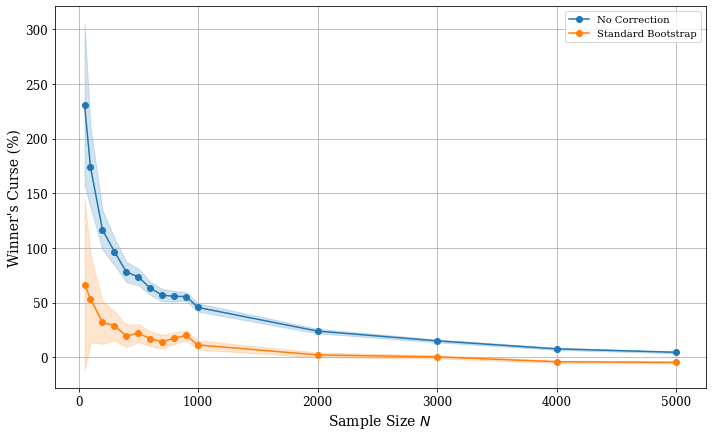

In [31]:
ber_nc_wc_avg = np.array([result_dict['rank_and_select_nc_wc_avg'] for result_dict in bernoulli_sample_size_result_dict.values()]) / 0.01 * 100
ber_nc_wc_se = np.array([result_dict['rank_and_select_nc_wc_se'] for result_dict in bernoulli_sample_size_result_dict.values()]) / 0.01 * 100

ber_boot_wc_avg = np.array([result_dict['rank_and_select_standard_bootstrap_wc_avg'] for result_dict in bernoulli_sample_size_result_dict.values()]) / 0.01 * 100
ber_boot_wc_se = np.array([result_dict['rank_and_select_standard_bootstrap_wc_se'] for result_dict in bernoulli_sample_size_result_dict.values()]) / 0.01 * 100

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.plot(sample_size_list, ber_nc_wc_avg, label='No Correction', color='C0', marker='o')
ax.fill_between(
    sample_size_list, 
    ber_nc_wc_avg - 1.96 * ber_nc_wc_se, 
    ber_nc_wc_avg + 1.96 * ber_nc_wc_se, 
    alpha=0.2, color='C0'
)
ax.plot(sample_size_list, ber_boot_wc_avg, label='Standard Bootstrap', color='C1', marker='o')
ax.fill_between(
    sample_size_list, 
    ber_boot_wc_avg - 1.96 * ber_boot_wc_se, 
    ber_boot_wc_avg + 1.96 * ber_boot_wc_se, 
    alpha=0.2, color='C1'
)

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

In [25]:
dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(0.1), PointMass(0.11)],
    'response_type': 'logit',
    'dgp_seed': 0
}

logit_sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=False, 
        n_jobs=-1
    )

    # truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    logit_sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True,  # remove outliers due to numerical instability
    )

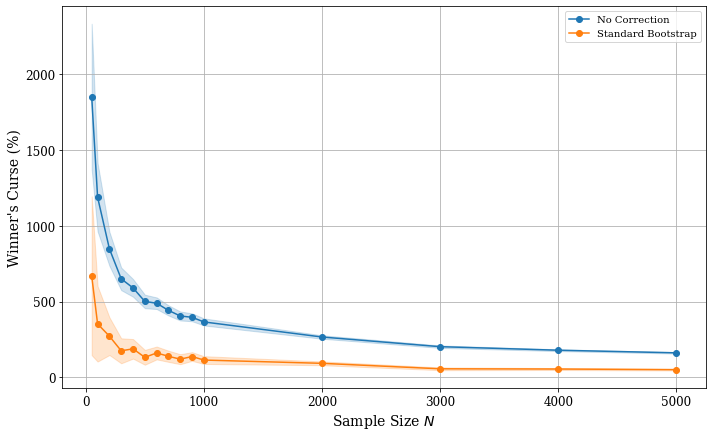

In [32]:
log_nc_wc_avg = np.array([result_dict['rank_and_select_nc_wc_avg'] for result_dict in logit_sample_size_result_dict.values()]) / 0.01 * 100
log_nc_wc_se = np.array([result_dict['rank_and_select_nc_wc_se'] for result_dict in logit_sample_size_result_dict.values()]) / 0.01 * 100

log_boot_wc_avg = np.array([result_dict['rank_and_select_standard_bootstrap_wc_avg'] for result_dict in logit_sample_size_result_dict.values()]) / 0.01 * 100
log_boot_wc_se = np.array([result_dict['rank_and_select_standard_bootstrap_wc_se'] for result_dict in logit_sample_size_result_dict.values()]) / 0.01 * 100

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.plot(sample_size_list, log_nc_wc_avg, label='No Correction', color='C0', marker='o')
ax.fill_between(
    sample_size_list, 
    log_nc_wc_avg - 1.96 * log_nc_wc_se, 
    log_nc_wc_avg + 1.96 * log_nc_wc_se, 
    alpha=0.2, color='C0'
)
ax.plot(sample_size_list, log_boot_wc_avg, label='Standard Bootstrap', color='C1', marker='o')
ax.fill_between(
    sample_size_list, 
    log_boot_wc_avg - 1.96 * log_boot_wc_se, 
    log_boot_wc_avg + 1.96 * log_boot_wc_se, 
    alpha=0.2, color='C1'
)

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

In [366]:
# bernoulli specification
ber_dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(0.1), PointMass(0.1 + 0.0222)],
    # 'base_effects': [PointMass(0.1), PointMass(0.1 + 0.0155)],
    'response_type': 'bernoulli', 
    'dgp_seed': 0
}

# continuous specification
cont_dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.05)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'response_type': 'continuous', 
    'dgp_seed': 0
}

# # logit specification
# log_dgp_params = {
#     'n_experiments': 1, 
#     'base_effects': [PointMass(np.log(1 / 9)), PointMass(np.log(11 / 89))],
#     'response_type': 'logit', 
#     'dgp_seed': 0
# }

optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 50000}

estimators_dict = {}

sample_size_list = [50, 100, 500, 1000, 2500, 5000, 10000]

In [367]:
ber_sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}
cont_sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    cont_result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=cont_dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )
    cont_sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=cont_result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
    )

    ber_result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=ber_dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )
    ber_sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=ber_result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
    )


Sample Size = 50
Running 50000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 10220 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 50000 out of 50000 | elapsed:    1.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s


Running 50000 experiments...


[Parallel(n_jobs=-1)]: Done 10220 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 50000 out of 50000 | elapsed:    0.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s



Sample Size = 100
Running 50000 experiments...


...

[Parallel(n_jobs=-1)]: Done 10220 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 50000 out of 50000 | elapsed:    2.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s



Sample Size = 10000
Running 50000 experiments...


[Parallel(n_jobs=-1)]: Done 10220 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 50000 out of 50000 | elapsed:    3.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s


Running 50000 experiments...


[Parallel(n_jobs=-1)]: Done 10220 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 50000 out of 50000 | elapsed:    2.7s finished


In [368]:
sample_size_list = list(cont_sample_size_result_dict.keys())

cont_nc_wc_avg = np.array([result_dict['rank_and_select_nc_wc_avg'] for result_dict in cont_sample_size_result_dict.values()]) / 0.05 * 100
cont_nc_wc_se = np.array([result_dict['rank_and_select_nc_wc_se'] for result_dict in cont_sample_size_result_dict.values()]) / 0.05 * 100
ber_nc_wc_avg = np.array([result_dict['rank_and_select_nc_wc_avg'] for result_dict in ber_sample_size_result_dict.values()]) / 0.0222 * 100
ber_nc_wc_se = np.array([result_dict['rank_and_select_nc_wc_se'] for result_dict in ber_sample_size_result_dict.values()]) / 0.0222 * 100

wc_avg_df = pd.DataFrame({
    'Sample Size': sample_size_list,
    'Continuous': cont_nc_wc_avg,
    'Bernoulli': ber_nc_wc_avg,
}).set_index('Sample Size').T

wc_se_df = pd.DataFrame({
    'Sample Size': sample_size_list,
    'Continuous': cont_nc_wc_se,
    'Bernoulli': ber_nc_wc_se,
}).set_index('Sample Size').T

In [369]:
wc_avg_df 

Sample Size,50,100,500,1000,2500,5000,10000
Continuous,153.449509,105.882559,37.502850,19.015140,5.088185,0.742467,-0.006791
Bernoulli,111.858757,74.089532,20.646216,7.633171,0.875117,-0.065964,-0.000333


In [370]:
wc_se_df

Sample Size,50,100,500,1000,2500,5000,10000
Continuous,23.597836,12.057831,2.577540,1.348222,0.564052,0.283136,0.141975
Bernoulli,17.867509,8.936088,1.954392,1.015625,0.414578,0.208992,0.104586


In [371]:
latex_dict = {'Continuous': {}, 'Bernoulli': {}}

for idx, sample_size in enumerate(sample_size_list):
    cont_wc_avg = wc_avg_df.loc['Continuous'][sample_size]
    cont_wc_se = wc_se_df.loc['Continuous'][sample_size]
    cont_sig_level = significance_level(cont_wc_avg, cont_wc_se)
    cont_sig_level = '^{' + cont_sig_level + '}' if cont_sig_level != '' else ''
    latex_dict['Continuous'][f'$N={sample_size}$'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${cont_wc_avg:.2f}\%" + cont_sig_level + f"$\\\\ (${cont_wc_se:.2f}\%$)" + "\end{tabular}"

    ber_wc_avg = wc_avg_df.loc['Bernoulli'][sample_size]
    ber_wc_se = wc_se_df.loc['Bernoulli'][sample_size]
    ber_sig_level = significance_level(ber_wc_avg, ber_wc_se)
    ber_sig_level = '^{' + ber_sig_level + '}' if ber_sig_level != '' else ''
    latex_dict['Bernoulli'][f'$N={sample_size}$'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${ber_wc_avg:.2f}\%" + ber_sig_level + f"$\\\\ (${ber_wc_se:.2f}\%$)" + "\end{tabular}"

latex_df = pd.DataFrame(latex_dict).T
print(latex_df.style.to_latex(
    column_format='c' * (len(sample_size_list) + 1), 
    hrules=True, 
))

\begin{tabular}{cccccccc}
\toprule
 & $N=50$ & $N=100$ & $N=500$ & $N=1000$ & $N=2500$ & $N=5000$ & $N=10000$ \\
\midrule
Continuous & \begin{tabular}[c]{@{}c@{}}$153.45\%^{***}$\\ ($23.60\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$105.88\%^{***}$\\ ($12.06\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$37.50\%^{***}$\\ ($2.58\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$19.02\%^{***}$\\ ($1.35\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$5.09\%^{***}$\\ ($0.56\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.74\%^{***}$\\ ($0.28\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.01\%$\\ ($0.14\%$)\end{tabular} \\
Bernoulli & \begin{tabular}[c]{@{}c@{}}$111.86\%^{***}$\\ ($17.87\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$74.09\%^{***}$\\ ($8.94\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$20.65\%^{***}$\\ ($1.95\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$7.63\%^{***}$\\ ($1.02\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.88\%^{**}$\\ ($0.41\%$)\end{tabular} & \begi